In [6]:
import pandas as pd

df = pd.read_csv(
    "data/Electric_Vehicle_Charging_Station_Data.csv"
)

df.head()

,Station_Name,Address,City,State_Province,Zip_Postal_Code,Start_Date___Time,Start_Time_Zone,End_Date___Time,End_Time_Zone,Total_Duration__hh_mm_ss_,Charging_Time__hh_mm_ss_,Energy__kWh_,GHG_Savings__kg_,Gasoline_Savings__gallons_,Port_Type,ObjectID,ObjectId2
0,BOULDER / JUNCTION ST1,2280 Junction Pl,Boulder,Colorado,80301,1/1/2018 17:49,MDT,1/1/2018 19:52,MDT,2:03:02,2:02:44,6.504,2.732,0.816,Level 2,0,1
1,BOULDER / JUNCTION ST1,2280 Junction Pl,Boulder,Colorado,80301,1/2/2018 8:52,MDT,1/2/2018 9:16,MDT,0:24:34,0:24:19,2.481,1.042,0.311,Level 2,1,2
2,BOULDER / JUNCTION ST1,2280 Junction Pl,Boulder,Colorado,80301,1/2/2018 21:11,MDT,1/3/2018 6:23,MDT,9:12:21,3:40:52,15.046,6.319,1.888,Level 2,2,3
3,BOULDER / ALPINE ST1,1275 Alpine Ave,Boulder,Colorado,80304,1/3/2018 9:19,MDT,1/3/2018 11:14,MDT,1:54:51,1:54:29,6.947,2.918,0.872,Level 2,3,4
4,BOULDER / BASELINE ST1,900 Baseline Rd,Boulder,Colorado,80302,1/3/2018 14:13,MDT,1/3/2018 14:30,MDT,0:16:58,0:16:44,1.800,0.756,0.226,Level 2,4,5


In [8]:
df.shape

(148136, 17)

In [9]:
df.columns

Index(['Station_Name', 'Address', 'City', 'State_Province', 'Zip_Postal_Code',
       'Start_Date___Time', 'Start_Time_Zone', 'End_Date___Time',
       'End_Time_Zone', 'Total_Duration__hh_mm_ss_',
       'Charging_Time__hh_mm_ss_', 'Energy__kWh_', 'GHG_Savings__kg_',
       'Gasoline_Savings__gallons_', 'Port_Type', 'ObjectID', 'ObjectId2'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148136 entries, 0 to 148135
Data columns (total 17 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Station_Name                148136 non-null  object 
 1   Address                     148136 non-null  object 
 2   City                        148136 non-null  object 
 3   State_Province              148136 non-null  object 
 4   Zip_Postal_Code             148136 non-null  int64  
 5   Start_Date___Time           148136 non-null  object 
 6   Start_Time_Zone             148136 non-null  object 
 7   End_Date___Time             148132 non-null  object 
 8   End_Time_Zone               148136 non-null  object 
 9   Total_Duration__hh_mm_ss_   148136 non-null  object 
 10  Charging_Time__hh_mm_ss_    148136 non-null  object 
 11  Energy__kWh_                148136 non-null  float64
 12  GHG_Savings__kg_            148136 non-null  float64
 13  Gasoline_Savin

In [11]:
df.isnull().sum()

Station_Name                  0
Address                       0
City                          0
State_Province                0
Zip_Postal_Code               0
Start_Date___Time             0
Start_Time_Zone               0
End_Date___Time               4
End_Time_Zone                 0
Total_Duration__hh_mm_ss_     0
Charging_Time__hh_mm_ss_      0
Energy__kWh_                  0
GHG_Savings__kg_              0
Gasoline_Savings__gallons_    0
Port_Type                     0
ObjectID                      0
ObjectId2                     0
dtype: int64

In [12]:
df.duplicated().sum()

0

In [13]:
df.describe()

,Zip_Postal_Code,Energy__kWh_,GHG_Savings__kg_,Gasoline_Savings__gallons_,ObjectID,ObjectId2
count,148136.000000,148136.000000,148136.000000,148136.000000,148136.000000,148136.000000
mean,80302.583045,8.456551,5.300949,1.061298,37134.811471,74068.500000
std,1.119734,8.873097,5.988745,1.113573,21556.186954,42763.324076
min,80301.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,80302.000000,2.803750,1.588000,0.352000,18516.750000,37034.750000
50%,80302.000000,6.217000,3.698000,0.780000,37033.500000,74068.500000
75%,80303.000000,11.391000,6.922000,1.430000,55550.250000,111102.250000
max,80305.000000,92.691000,65.811000,11.633000,77941.000000,148136.000000


In [14]:
df = df.dropna(subset=["End_Date___Time"])

In [15]:
df.shape

(148132, 17)

In [16]:
df = df.drop(
    columns=["ObjectID","ObjectId2"]
)

In [17]:
df.columns

Index(['Station_Name', 'Address', 'City', 'State_Province', 'Zip_Postal_Code',
       'Start_Date___Time', 'Start_Time_Zone', 'End_Date___Time',
       'End_Time_Zone', 'Total_Duration__hh_mm_ss_',
       'Charging_Time__hh_mm_ss_', 'Energy__kWh_', 'GHG_Savings__kg_',
       'Gasoline_Savings__gallons_', 'Port_Type'],
      dtype='object')

In [18]:
df["Start_Date___Time"] = pd.to_datetime(
    df["Start_Date___Time"]
)

df["End_Date___Time"] = pd.to_datetime(
    df["End_Date___Time"]
)

In [19]:
df["Start_Date___Time"].min()

Timestamp('2018-01-01 17:49:00')

In [20]:
df["Start_Date___Time"].max()

Timestamp('2023-11-30 23:27:00')

In [21]:
df["Month"] = df["Start_Date___Time"].dt.month

In [22]:
monthly_sessions = df.groupby("Month").size()

In [23]:
monthly_sessions

Month
1     10358
2     10044
3     10516
4     11684
5     12634
6     13974
7     15392
8     16158
9     13007
10    13274
11    11473
12     9618
dtype: int64

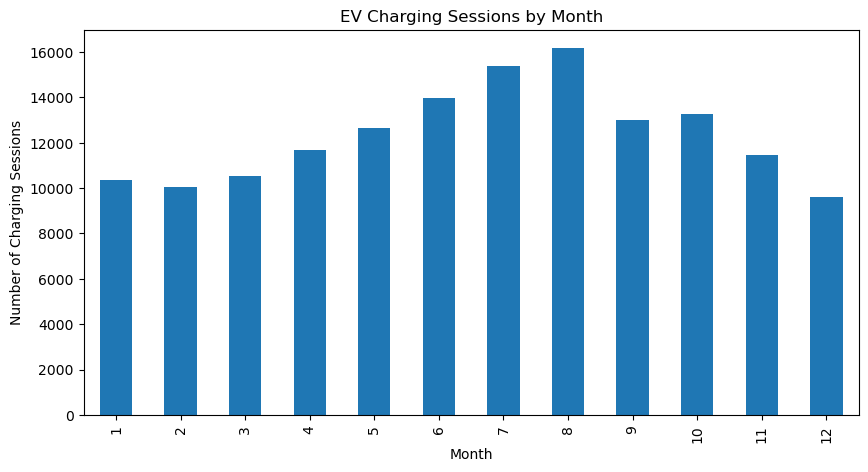

In [24]:
import matplotlib.pyplot as plt
monthly_sessions.plot(
    kind="bar",
    figsize=(10,5)
)

plt.xlabel("Month")
plt.ylabel("Number of Charging Sessions")
plt.title("EV Charging Sessions by Month")

plt.show()

In [25]:
df["Year_Month"] = df["Start_Date___Time"].dt.to_period("M")

In [26]:
monthly_trend = df.groupby("Year_Month").size()

monthly_trend.head()

Year_Month
2018-01     418
2018-02     616
2018-03     784
2018-04     920
2018-05    1242
Freq: M, dtype: int64

In [27]:
monthly_trend.tail()

Year_Month
2023-07    5426
2023-08    5462
2023-09    2783
2023-10    2592
2023-11    2373
Freq: M, dtype: int64

In [28]:
monthly_trend.shape

(71,)

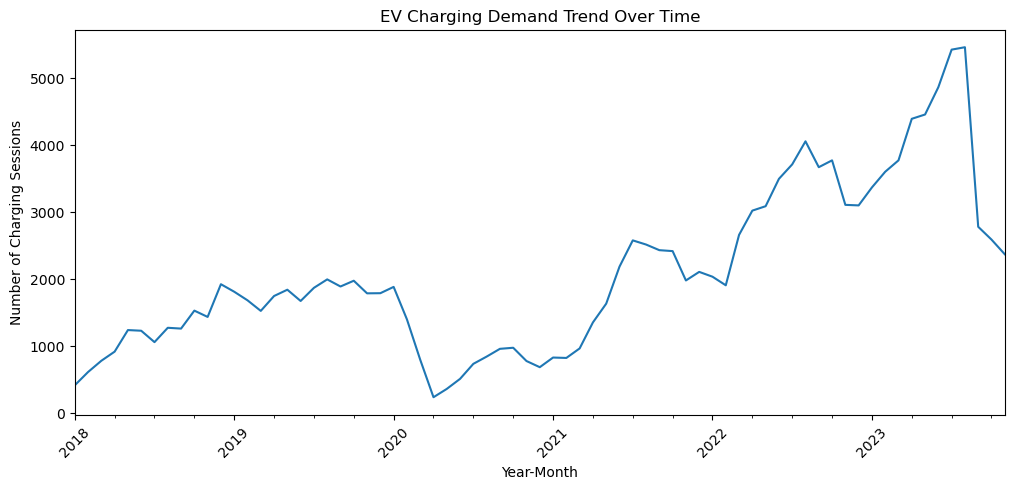

In [29]:
import matplotlib.pyplot as plt

monthly_trend.plot(
    figsize=(12,5)
)

plt.xlabel("Year-Month")
plt.ylabel("Number of Charging Sessions")
plt.title("EV Charging Demand Trend Over Time")

plt.xticks(rotation=45)

plt.show()